# Comparing OOI In-Situ Sea Surface Temperature with NASA Satellite SST

This notebook demonstrates how to combine OOI science data with an independent,
external dataset to **cross-validate a measurement**. Most of the OOI example
notebooks document the workflow for a single instrument. This one does something
different: it pulls a temperature record from an OOI mooring *and* an
independently produced satellite temperature record for the same place and time,
and asks how well they agree.

That pattern is useful any time you want to build confidence in a measurement,
detect sensor drift or bias, or fill gaps in one record with another.

**What we compare**

- **OOI in-situ:** the CTD on the Near-Surface Instrument Frame (NSIF, ~7 m
  depth) of the Coastal Endurance Oregon Shelf Surface Mooring (`CE02SHSM`). This
  is the same instrument used in the introductory M2M example, so the access
  pattern should be familiar.
- **NASA satellite:** the JPL **Multi-scale Ultra-high Resolution (MUR)** SST
  product (`MUR-JPL-L4-GLOB-v4.1`) — a daily, gap-free, 1 km *foundation* SST
  analysis produced under the NASA MEaSUREs program. We access it through the
  NOAA CoastWatch ERDDAP server, which needs no login.

**One idea to keep in mind**

These two numbers are *not* measuring exactly the same thing. The satellite
"sees" a temperature representative of the very top of the ocean (a skin/
foundation temperature), while the CTD sits at about 7 m. On a calm, well-mixed
day they should agree closely; during summer upwelling or strong surface heating
they can diverge by a degree or more. That difference is **physically
meaningful, not just measurement error** — and interpreting it is the
scientifically interesting part of this notebook.

**Workflow**

1. Pull the OOI CTD temperature record and clean it using its QARTOD quality flags.
2. Pull the co-located MUR satellite SST for the same dates.
3. Put both on a common daily timeline and compare them (time series, scatter, statistics).
4. Interpret the agreement and the differences.


## Setup

We use `xarray` for the OOI NetCDF data, `pandas` for tabular alignment of the
two records, `requests` to call the ERDDAP service, and `matplotlib` for plots.
The only OOI-specific import is `load_gc_thredds`, which downloads the pre-built
"gold copy" NetCDF for an instrument directly (no asynchronous request queue).


In [1]:
%matplotlib inline
import numpy as np
import pandas as pd
import xarray as xr
import requests
from io import StringIO
import matplotlib.pyplot as plt

from ooi_data_explorations.common import load_gc_thredds

plt.rcParams.update({'font.size': 13})

## Part 1 — OOI in-situ temperature

### Define the instrument and time window

We identify a single physical instrument with its **reference designator**
(`site`-`node`-`sensor`), plus the delivery `method` and the data `stream`. We
also choose a time window. A full calendar year is a good choice here: it lets
us see whether the satellite and in-situ records track the *seasonal cycle*
together, which is a much stronger validation than a single month.


In [2]:
# Reference designator for the CE02SHSM NSIF CTD (~7 m depth)
site   = 'CE02SHSM'
node   = 'RID27'
sensor = '03-CTDBPC000'
method = 'recovered_host'
stream = 'ctdbp_cdef_dcl_instrument_recovered'

# Analysis window (one full year)
start_date = '2022-01-01'
stop_date  = '2022-12-31'

print(f'Instrument : {site}-{node}-{sensor}')
print(f'Window     : {start_date} -> {stop_date}')

Instrument : CE02SHSM-RID27-03-CTDBPC000
Window     : 2022-01-01 -> 2022-12-31


### Download and subset the data

`load_gc_thredds` returns the full gold-copy record as an `xarray.Dataset`, so we
immediately subset to our window. The regex `tag` restricts the download to the
CTDBP NetCDF files for this instrument.


In [4]:
tag = r'.*CTDBP.*\.nc$'
ctd = load_gc_thredds(site, node, sensor, method, stream, tag)

ctd = ctd.sortby('time').drop_duplicates(dim='time')

# Restrict to the analysis window
ctd = ctd.sel(time=slice(start_date, stop_date))

print(f'{ctd.time.size} records between '
      f'{str(ctd.time.values.min())[:10]} and {str(ctd.time.values.max())[:10]}')

Merging the data files into a single dataset


26863 records between 2022-03-29 and 2022-12-31


### Apply quality control

OOI attaches automated **QARTOD** quality flags to each data point, where
`1 = pass`, `3 = suspect`, and `4 = fail`. Before comparing against anything, we
remove the points flagged `fail`. Doing this explicitly (rather than trusting the
raw record) is what makes a validation defensible — we want to compare the
satellite against *good* in-situ data, not against a fouled or malfunctioning
sensor.

If the expected flag variable is not present, it
says so and proceeds without filtering rather than crashing.


In [5]:
temp_var = 'sea_water_temperature'
flag_var = 'sea_water_temperature_qartod_results'

if temp_var not in ctd.variables:
    # Fall back to common alternative names if needed
    for alt in ['temp', 'ctdbp_seawater_temperature']:
        if alt in ctd.variables:
            temp_var = alt
            break
    print(f'Using temperature variable: {temp_var}')

if flag_var in ctd.variables:
    n_total = int(ctd[flag_var].size)
    n_fail  = int((ctd[flag_var] == 4).sum())
    # Keep everything that is NOT flagged fail (replaces fails with NaN)
    ctd_good = ctd.where(ctd[flag_var] != 4)
    print(f'QARTOD: dropped {n_fail} of {n_total} points flagged fail (=4).')
else:
    print(f'"{flag_var}" not found - proceeding without QARTOD filtering.')
    ctd_good = ctd

QARTOD: dropped 0 of 26863 points flagged fail (=4).


### Get the mooring location and compute daily means

To ask the satellite for "the same place," we need the mooring's coordinates. We
read them straight from the dataset (with the
published `CE02SHSM` position as a fallback). We also resample the in-situ
temperature to daily means, so it lines up with the daily satellite product.


In [6]:
def get_coord(ds, names):
    for n in names:
        if n in ds.variables:
            v = np.asarray(ds[n].values, dtype='float64')
            v = v[np.isfinite(v)]
            if v.size:
                return float(np.mean(v))
    return None

mooring_lat = get_coord(ctd_good, ['lat', 'latitude'])
mooring_lon = get_coord(ctd_good, ['lon', 'longitude'])

if mooring_lat is None or mooring_lon is None:
    mooring_lat, mooring_lon = 44.6393, -124.3033   # published CE02SHSM location
    print('Coordinates not found in dataset - using published CE02SHSM position.')

print(f'Mooring location: {mooring_lat:.4f} N, {mooring_lon:.4f} E')

Coordinates not found in dataset - using published CE02SHSM position.
Mooring location: 44.6393 N, -124.3033 E


In [7]:
# Daily-mean in-situ temperature as a tidy DataFrame
insitu_daily = ctd_good[temp_var].resample(time='1D').mean()
insitu_df = insitu_daily.to_dataframe().reset_index()[['time', temp_var]].dropna()
insitu_df = insitu_df.rename(columns={temp_var: 'insitu_sst'})
insitu_df['date'] = insitu_df['time'].dt.floor('D')

print(f'{len(insitu_df)} daily in-situ values')
insitu_df.head()

278 daily in-situ values


,time,insitu_sst,date
0,2022-03-29,9.846533,2022-03-29
1,2022-03-30,9.956581,2022-03-30
2,2022-03-31,10.040526,2022-03-31
3,2022-04-01,9.925775,2022-04-01
4,2022-04-02,9.743900,2022-04-02


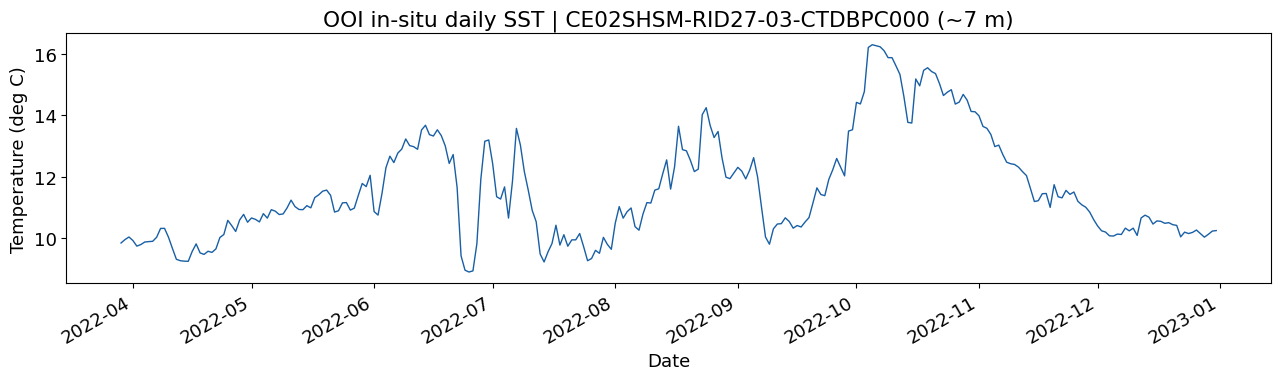

In [8]:
fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(insitu_df['date'], insitu_df['insitu_sst'], '-', lw=1, color='#185FA5')
ax.set_xlabel('Date'); ax.set_ylabel('Temperature (deg C)')
ax.set_title(f'OOI in-situ daily SST | {site}-{node}-{sensor} (~7 m)')
fig.autofmt_xdate(); plt.tight_layout(); plt.show()

## Part 2 — NASA satellite SST (MUR)

The **MUR** product blends measurements from several satellite radiometers (and
some in-situ data) into a single daily, gap-free, 0.01-degree (~1 km) global
field. The variable we want is `analysed_sst`. We pull a single grid cell — the
one nearest the mooring — for our date range.

We use the CoastWatch **ERDDAP `griddap`** service. A `griddap` request URL has
the form:

```
.../griddap/jplMURSST41.csv?analysed_sst[(time_start):stride:(time_stop)][(lat)][(lon)]
```

Giving a single value in `(...)` for latitude and longitude tells ERDDAP to
return the nearest grid cell. MUR's daily timestamps fall at `09:00:00Z`, so we
build the time bounds accordingly.

> **Network / units notes.** This requires your JupyterHub to reach
> `coastwatch.pfeg.noaa.gov`. If that host is blocked or slow, the same dataset
> (`jplMURSST41`) is mirrored on other ERDDAP servers — try
> `https://upwell.pfeg.noaa.gov/erddap/` or `https://coastwatch.noaa.gov/erddap/`.
> The function below also checks the returned units and converts Kelvin to
> Celsius if necessary, so it is robust to either convention.


In [13]:
def fetch_mur_sst(lat, lon, start, stop,
                  base='https://coastwatch.pfeg.noaa.gov/erddap/griddap/jplMURSST41.csv'):
    '''Return a DataFrame of daily MUR analysed_sst (deg C) for the grid cell
    nearest (lat, lon), over [start, stop]. Dates are 'YYYY-MM-DD' strings.'''
    t0 = f'{start}T09:00:00Z'
    t1 = f'{stop}T09:00:00Z'
    query = f'analysed_sst[({t0}):1:({t1})][({lat})][({lon})]'
    url = f'{base}?{query}'

    resp = requests.get(url, timeout=180)
    resp.raise_for_status()

    # ERDDAP CSV: row 0 = column names (header), row 1 = units, then data
    raw = pd.read_csv(StringIO(resp.text))
    units = str(raw.iloc[0]['analysed_sst'])
    df = raw.iloc[1:].copy()
    df['time'] = pd.to_datetime(df['time'])
    df['analysed_sst'] = pd.to_numeric(df['analysed_sst'], errors='coerce')
    df['latitude']  = pd.to_numeric(df['latitude'],  errors='coerce')
    df['longitude'] = pd.to_numeric(df['longitude'], errors='coerce')
    
    # Convert to Celsius if the server returned Kelvin
    if units.lower().startswith('k') or df['analysed_sst'].median(skipna=True) > 100:
        df['analysed_sst'] = df['analysed_sst'] - 273.15
        print('Converted satellite SST from Kelvin to Celsius.')

    return df[['time', 'latitude', 'longitude', 'analysed_sst']], url

sat_df, mur_url = fetch_mur_sst(mooring_lat, mooring_lon, start_date, stop_date)
sat_df['date'] = pd.to_datetime(sat_df['time'], utc=True).dt.tz_localize(None).dt.floor('D')
sat_df = sat_df.rename(columns={'analysed_sst': 'satellite_sst'})

print(f'{len(sat_df)} daily satellite values')
print(f'Nearest MUR grid cell: {sat_df["latitude"].iloc[0]:.3f} N, '
      f'{sat_df["longitude"].iloc[0]:.3f} E')
sat_df[['date', 'satellite_sst']].head()

365 daily satellite values
Nearest MUR grid cell: 44.640 N, -124.300 E


,date,satellite_sst
1,2022-01-01,9.099
2,2022-01-02,9.098
3,2022-01-03,9.472
4,2022-01-04,9.745
5,2022-01-05,9.790


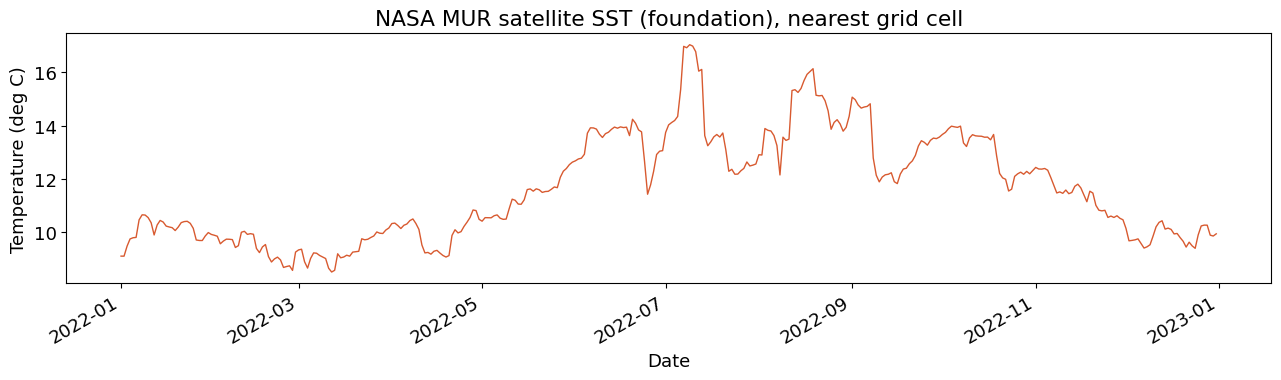

In [14]:
fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(sat_df['date'], sat_df['satellite_sst'], '-', lw=1, color='#D85A30')
ax.set_xlabel('Date'); ax.set_ylabel('Temperature (deg C)')
ax.set_title('NASA MUR satellite SST (foundation), nearest grid cell')
fig.autofmt_xdate(); plt.tight_layout(); plt.show()

### Alternative: pulling MUR directly from NASA with `earthaccess`

The cells above use ERDDAP because it needs no credentials. If you want to use
NASA's own data system directly (PO.DAAC), the `earthaccess` library is the
standard route. It requires a free **NASA Earthdata Login** account. The cell
below is left commented out so the notebook runs without credentials; uncomment
it to try the direct path.


In [ ]:
# OPTIONAL - requires a free NASA Earthdata Login account.
#
# import earthaccess
# auth = earthaccess.login()              # prompts for credentials, or reads ~/.netrc
# results = earthaccess.search_data(
#     short_name='MUR-JPL-L4-GLOB-v4.1',
#     temporal=(start_date, stop_date),
#     bounding_box=(mooring_lon - 0.05, mooring_lat - 0.05,
#                   mooring_lon + 0.05, mooring_lat + 0.05),
# )
# files = earthaccess.open(results)
# mur = xr.open_mfdataset(files)
# sat_point = (mur['analysed_sst']
#              .sel(lat=mooring_lat, lon=mooring_lon, method='nearest') - 273.15)
# sat_point.to_dataframe().head()

## Part 3 — Align and compare

We merge the two daily records on their shared dates (an inner join keeps only
days present in both), then look at them three ways: overlaid time series, a
scatter against the 1:1 line, and a few summary statistics.


In [15]:
merged = pd.merge(
    insitu_df[['date', 'insitu_sst']],
    sat_df[['date', 'satellite_sst']],
    on='date', how='inner'
).dropna().sort_values('date').reset_index(drop=True)

print(f'{len(merged)} days with both in-situ and satellite values')
merged.head()

278 days with both in-situ and satellite values


,date,insitu_sst,satellite_sst
0,2022-03-29,9.846533,9.949
1,2022-03-30,9.956581,10.079
2,2022-03-31,10.040526,10.155
3,2022-04-01,9.925775,10.323
4,2022-04-02,9.743900,10.340


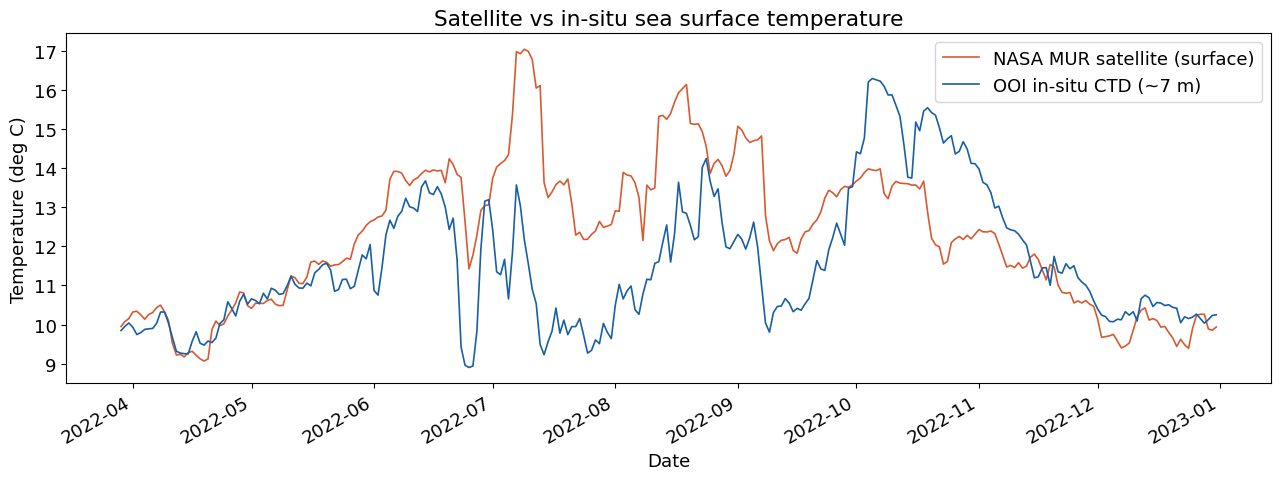

In [16]:
fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(merged['date'], merged['satellite_sst'], '-', lw=1.2,
        color='#D85A30', label='NASA MUR satellite (surface)')
ax.plot(merged['date'], merged['insitu_sst'], '-', lw=1.2,
        color='#185FA5', label='OOI in-situ CTD (~7 m)')
ax.set_xlabel('Date'); ax.set_ylabel('Temperature (deg C)')
ax.set_title('Satellite vs in-situ sea surface temperature')
ax.legend(); fig.autofmt_xdate(); plt.tight_layout(); plt.show()

In [17]:
# Comparison statistics
diff  = merged['insitu_sst'] - merged['satellite_sst']   # in-situ minus satellite
bias  = diff.mean()
rmsd  = np.sqrt((diff ** 2).mean())
corr  = merged['insitu_sst'].corr(merged['satellite_sst'])
slope, intercept = np.polyfit(merged['satellite_sst'], merged['insitu_sst'], 1)

print(f'Mean bias (in-situ - satellite) : {bias:+.2f} deg C')
print(f'RMS difference                  : {rmsd:.2f} deg C')
print(f'Correlation (r)                 : {corr:.3f}')
print(f'Regression slope / intercept    : {slope:.3f} / {intercept:+.2f}')

Mean bias (in-situ - satellite) : -0.67 deg C
RMS difference                  : 1.89 deg C
Correlation (r)                 : 0.501
Regression slope / intercept    : 0.466 / +5.87


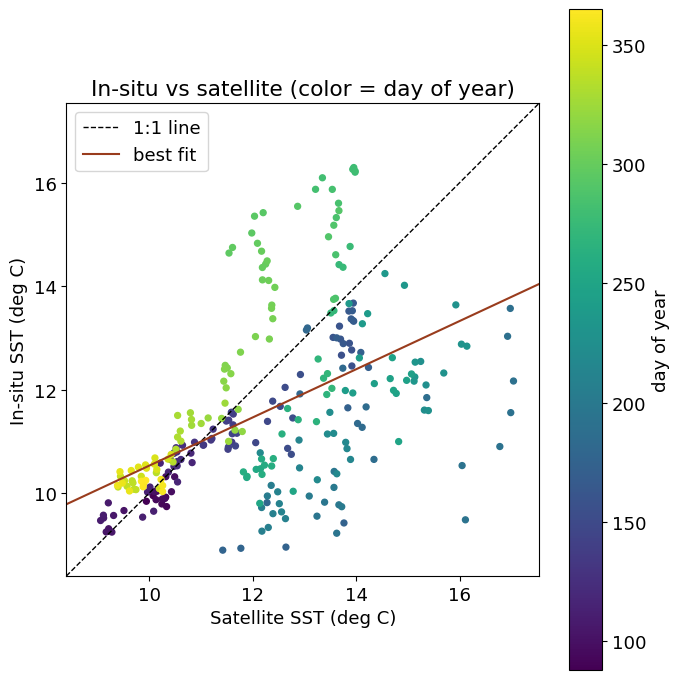

In [18]:
lo = float(min(merged['satellite_sst'].min(), merged['insitu_sst'].min())) - 0.5
hi = float(max(merged['satellite_sst'].max(), merged['insitu_sst'].max())) + 0.5

fig, ax = plt.subplots(figsize=(7, 7))
sc = ax.scatter(merged['satellite_sst'], merged['insitu_sst'],
                c=merged['date'].dt.dayofyear, cmap='viridis', s=18)
ax.plot([lo, hi], [lo, hi], 'k--', lw=1, label='1:1 line')
ax.plot([lo, hi], [slope * lo + intercept, slope * hi + intercept],
        '-', color='#993C1D', lw=1.5, label='best fit')
ax.set_xlim(lo, hi); ax.set_ylim(lo, hi); ax.set_aspect('equal')
ax.set_xlabel('Satellite SST (deg C)'); ax.set_ylabel('In-situ SST (deg C)')
ax.set_title('In-situ vs satellite (color = day of year)')
ax.legend(loc='upper left')
fig.colorbar(sc, ax=ax, label='day of year'); plt.tight_layout(); plt.show()

## Part 4 — Interpreting the comparison

For the 2022 record at `CE02SHSM`, the comparison produced:

| Metric | Value |
|---|---|
| Mean bias (in-situ − satellite) | **−0.67 °C** |
| RMS difference | **1.89 °C** |
| Correlation (r) | **0.50** |
| Regression slope / intercept | **0.47 / +5.87** |

At first glance a correlation of 0.50 looks weak. This does not mean that something is not working but it is the signature of real ocean physics, and the scatter
plot (colored by day of year) shows exactly what is going on. The key is that the
satellite measures a near-surface *foundation* temperature while the CTD sits at
about 7 m, so the two only agree when the upper water column is well mixed.

**Reading the seasonal structure**

- **Spring and December (well-mixed):** the early-year and late-year points sit
  tightly on the 1:1 line around 9–11 °C. When the column is mixed, the surface
  and 7 m are the same water, and the two independent instruments agree almost
  perfectly. This is the mutual validation we were looking for.
- **Mid-summer (below the 1:1 line):** the satellite reads warmer than the CTD.
  This is the **upwelling signature** on the Oregon shelf — northerly winds push
  warm surface water offshore and draw cold water up to 7 m, so the surface
  (satellite) and 7 m (CTD) are sampling different water. The sharp
  cold dips in the in-situ time series during July–August are these upwelling
  pulses.
- **Fall (above the 1:1 line):** the CTD reads warmer than the satellite,
  consistent with autumn surface cooling — the skin/foundation layer loses heat
  to the atmosphere while the 7 m water still holds summer warmth.

**Why the annual statistics look modest**

The −0.67 °C annual bias is a *net* of a strongly negative summer and a positive
fall, and the r of 0.50 (with a slope well below 1) is low because a single
annual number averages across two physically distinct regimes. During summer the
surface and 7 m are partly decoupled — briefly even anti-correlated during
upwelling — and that pulls the whole-year fit down. In other words, the modest
correlation is the correct result for a coastal upwelling site: it tells us *when*
a satellite SST is a good proxy for 7 m temperature (well-mixed seasons) and when
it is not (active upwelling).

**A known limitation of the satellite product**

The near-vertical streaks in the scatter — where the satellite value barely moves
while the in-situ value swings — reflect MUR being a gap-free Level-4 analysis.
On cloudy stretches it interpolates rather than observes directly, smoothing real
day-to-day variability that the mooring still captures. This is a property of the
gridded product, not a flaw in the comparison, and it is worth stating plainly
whenever MUR is used as a reference.

**What can be improved**

Everything above interprets the data as collected; nothing was tuned to improve
the numbers. Legitimate next steps (see the summary) — averaging a small box of
satellite cells for better spatial representativeness, or reporting statistics
separately for the well-mixed and upwelling seasons — are justified by sampling
and physics. What would *not* be legitimate is removing individual points because
they hurt the correlation, applying an arbitrary offset, or trimming the date
range to a flattering window. The distinction is whether each choice can be
defended on physical grounds.

## Summary and how to extend this

This notebook combined an OOI in-situ temperature record with an independent NASA
satellite SST product, cleaned the in-situ data with its QARTOD flags, co-located
and time-matched the two, and quantified their agreement.

**What we found.** Across 2022 the satellite and 7 m mooring temperatures agree
closely in the well-mixed seasons (spring and late fall sit on the 1:1 line) and
diverge during summer, when coastal upwelling makes the surface and 7 m
genuinely different water masses. The annual correlation of about 0.50 and the
−0.67 °C mean bias are therefore not measurement error but a real, interpretable
consequence of vertical structure — the satellite is an excellent proxy for 7 m
temperature when the column is mixed, and a poor one when it is stratified or
upwelling.

**Planned and possible extensions.**

- **Spatial representativeness:** average a small box of MUR cells (e.g. ~0.1°)
  around the mooring instead of a single 1 km pixel. `CE02SHSM` sits near sharp
  upwelling fronts, so a box is more representative and reduces pixel noise. *(Planned as a follow-on.)*
- **Regime-separated statistics:** report the comparison separately for the
  well-mixed season and the upwelling season, rather than as one annual number.
  This compares like with like and makes explicit when the satellite is a good
  proxy. A monthly-bias plot is a good way to let the data define the split.
- **Other variables:** the natural next comparison is chlorophyll / ocean color —
  an OOI fluorometer (`FLORT`) or absorption sensor (`OPTAA`) against a NASA
  ocean-color product (e.g. MODIS-Aqua or PACE). The access pattern is the same;
  only the dataset ID and variable name change.
- **Other moorings:** change the reference designator to any OOI platform with a
  near-surface temperature sensor.

**Two reminders that keep a comparison like this trustworthy.** Always clean the
in-situ side with its quality flags before comparing, and always state plainly
what each instrument is physically measuring (here: a near-surface foundation
temperature versus a 7 m point measurement) before interpreting any difference
between them. The differences are often the most informative part of the result.